### Architecture
In this experiment, EfficientNet predictions and gbdt predictions are combined through late fusion. Both the models trained on 4 folds and validated on 1 fold, at the end all the OOF predictions are saved and in the fusion stage, both models predictions are combined through weighted average to get the final output

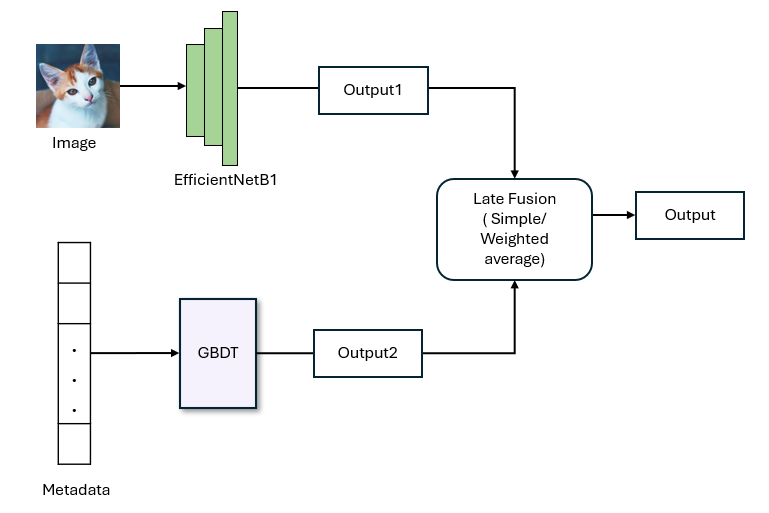
### Analysis SWIN + GBDT Late fusion
 EfficientNet is the stronger single model overall, GBDT is weaker alone, but their errors are different enough that combining them reduces RMSE in most bins and globally

 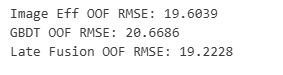
 
 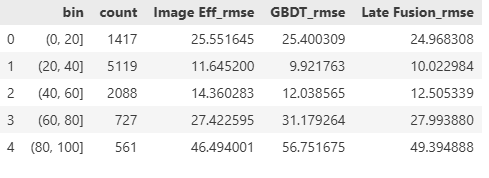

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [3]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image



main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp6")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp6"]   # define in config
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:



kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== Exp6_EffB1_256_Lite: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=27.2049 | ValRMSE: 19.9575
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=17.1192 | ValRMSE: 19.9062
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=14.5808 | ValRMSE: 20.1094
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=12.1051 | ValRMSE: 20.3685
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=10.3248 | ValRMSE: 20.7083
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=8.9130 | ValRMSE: 20.6444
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=8.0169 | ValRMSE: 20.6987
Early stopping at epoch 7
Fold 1 best RMSE: 19.9062

=== Exp6_EffB1_256_Lite: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=27.1771 | ValRMSE: 19.5499
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=17.1479 | ValRMSE: 19.7258
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=14.4286 | ValRMSE: 19.7962
Epoch 4/10 | Fold 2 | Train[MSE]: RMSE=11.8792 | ValRMSE: 19.9825
Epoch 5/10 | Fold 2 | Train[MSE]: RMSE=10.0370 | ValRMSE: 20.0426
Epoch 6/10 | Fold 2 | Train[MSE]: RMSE=8.7658 | ValRMSE: 20.1152
Early stopping at e

### Late Fusion
Here the the predictions (OOF predictions) of both experiments exp1(GBDT) and exp6(EfficientNetB1) are loaded and then merged on the basis of id, then at the end predictions are combined using simple average as well as optimal weights/weighted average

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error

# paths
main_folder = ".."
img_oof_path  = os.path.join(main_folder, "outputs", "exp6", "oof_detail.csv")
gbdt_oof_path = os.path.join(main_folder, "outputs", "exp1", "oof_detail.csv")  

img_oof  = pd.read_csv(img_oof_path)   # columns: Id, fold, ytrue, oof_pred, 
gbdt_oof = pd.read_csv(gbdt_oof_path)  # same columns: Id, ytrue, oof_pred




> fold number check in both experiment if the records are same in all folds

In [5]:
img_map = img_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)
gbdt_map = gbdt_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)

assert img_map.equals(gbdt_map), "Fold assignment differs! RMSE per fold will be wrong."

In [56]:
assert set(img_oof["Id"]) == set(gbdt_oof["Id"]), "IDs differ!"

> merging both experiments OOF

In [6]:
# inner join on Id to  alignment
oof = img_oof.merge(
    gbdt_oof[["Id", "oof_pred"]].rename(columns={"oof_pred": "gbdt_oof"}),
    on="Id",
    how="inner",
)

y_true = oof["ytrue"].values
img_pred = oof["oof_pred"].values
gbdt_pred = oof["gbdt_oof"].values

In [58]:
img_rmse = root_mean_squared_error(y_true, img_pred)
gbdt_rmse = root_mean_squared_error(y_true, gbdt_pred)
print("Image OOF RMSE:", img_rmse)
print("GBDT OOF RMSE:", gbdt_rmse)

Image OOF RMSE: 19.6039434522729
GBDT OOF RMSE: 20.668644721159303


In [8]:
# Residuals
img_res  = y_true - img_pred
gbdt_res = y_true - gbdt_pred

# Add to DataFrame if you like
oof["img_res"]  = img_res
oof["gbdt_res"] = gbdt_res

# Pearson correlation between errors
corr = np.corrcoef(img_res, gbdt_res)[0, 1]
print("Residual correlation:", corr)

Residual correlation: 0.839850578711091


> weighted average 

In [ ]:
from src.utils import late_fusion_from_oof

# oof
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="gbdt_oof",
    y_col="ytrue",
    fold_col="fold",
    mode="weighted",      # or "simple"
    n_grid=101,
)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])

oof_fused = oof_fused.rename(columns={"oof_pred": "Eff_oof"})

# save new OOF 
oof_fused.to_csv(os.path.join(main_folder, "outputs", "exp6", "Eff_GBDT_weighted_oof_detail.csv"),
                 index=False)
oof_fused.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(main_folder, "outputs", "exp6",  "Eff_GBDT_top50_errors.csv"), index=False
)


Global OOF RMSE: 19.2228003880724
Weights: 0.66 0.33999999999999997
Fold-wise RMSE: {1: 19.660142771700425, 2: 19.200389600164264, 3: 18.692749620431442, 4: 18.871775681922834, 5: 19.668074336220126}
Avg: 19.21862640208782 Std: 0.398528428757681


> simple average

In [72]:
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="gbdt_oof",
    y_col="ytrue",
    fold_col="fold",
    mode="simple",      # or "simple"

)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])


Global OOF RMSE: 19.31385963646861
Weights: 0.5 0.5
Fold-wise RMSE: {1: 19.7773014935422, 2: 19.296633261625377, 3: 18.801366325980926, 4: 18.994932970083163, 5: 19.680358266535013}
Avg: 19.310118463553337 Std: 0.3778068233028775


In [73]:
import pandas
df = pd.read_csv(out_dir+"/Eff_GBDT_weighted_oof_detail.csv")

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.final_pred)**2).mean() ** 0.5
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.6601 (n=1983)
Fold 2 OOF RMSE: 19.2004 (n=1983)
Fold 3 OOF RMSE: 18.6927 (n=1982)
Fold 4 OOF RMSE: 18.8718 (n=1982)
Fold 5 OOF RMSE: 19.6681 (n=1982)


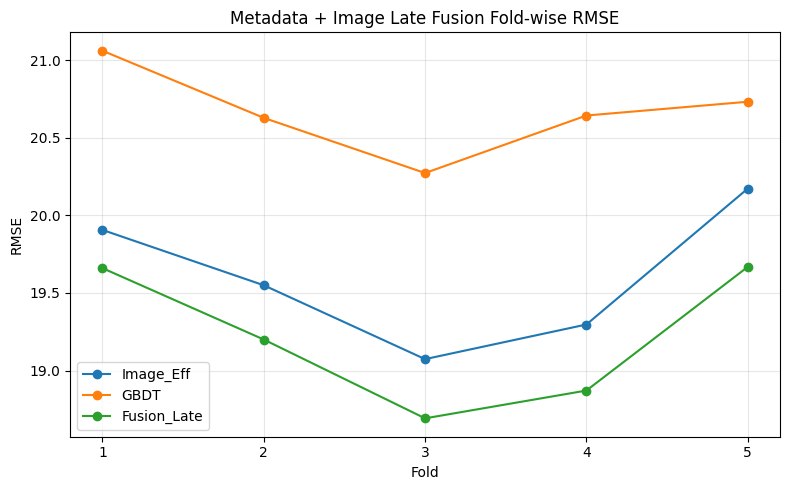

In [74]:
from src.plot import plot_foldwise_rmse
df = pd.read_csv(out_dir + "/Eff_GBDT_weighted_oof_detail.csv")

rmse_results = plot_foldwise_rmse(
    df,
    y_col="ytrue",
    pred_cols={
        "Image_Eff": "Eff_oof",
        "GBDT": "gbdt_oof",
        "Fusion_Late": "final_pred"
    },
    fold_col="fold",
    title="Metadata + Image Late Fusion Fold-wise RMSE",
)





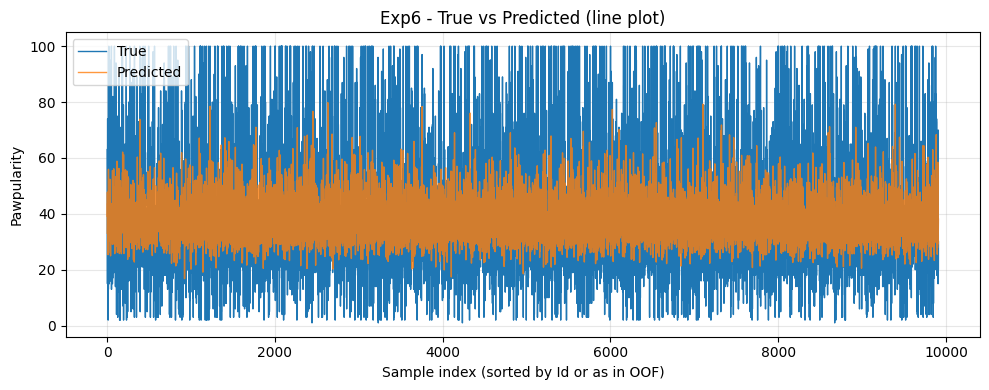

In [75]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

oof_df = df.rename(columns={"final_pred": "oof_pred"})


# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp6")

Image Eff OOF RMSE: 19.6039
GBDT OOF RMSE: 20.6686
Late Fusion OOF RMSE: 19.2228


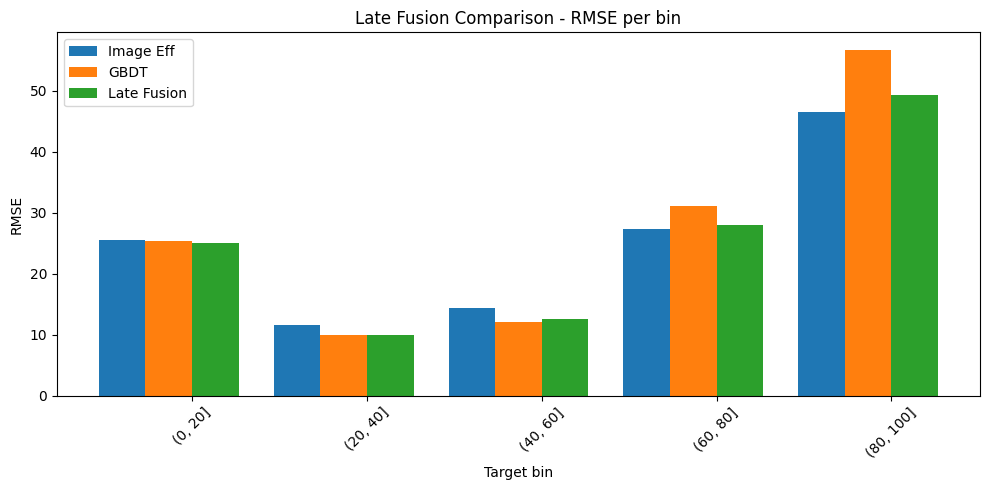

In [76]:
bins = [0, 20, 40, 60, 80, 100]
from src.plot import compare_oof_by_bins_multi

summary, overall = compare_oof_by_bins_multi(
    oof_df,
    bins=bins,
    y_col="ytrue",
    pred_cols={
        "Image Eff": "Eff_oof",
        "GBDT": "gbdt_oof",
        "Late Fusion": "oof_pred"
    },
    title_prefix="Late Fusion Comparison"
)

In [77]:
summary.head()

,bin,count,Image Eff_rmse,GBDT_rmse,Late Fusion_rmse
0,"(0, 20]",1417,25.551645,25.400309,24.968308
1,"(20, 40]",5119,11.645200,9.921763,10.022984
2,"(40, 60]",2088,14.360283,12.038565,12.505339
3,"(60, 80]",727,27.422595,31.179264,27.993880
4,"(80, 100]",561,46.494001,56.751675,49.394888


In [78]:
err_df = pd.read_csv(os.path.join(main_folder, "outputs", "exp6",  "Eff_GBDT_top50_errors.csv"))
err_df = err_df.rename(columns={"final_pred": "oof_pred"})

In [79]:
err_df.head()

,Id,fold,ytrue,Eff_oof,abs_err,gbdt_oof,oof_pred
0,e2ae437b18e6ca5261acc713ecda948f,4,100,16.838764,83.161236,42.156914,25.446935
1,b6f886a92a5dd3bdb2d1fb77ffd00848,5,19,99.584068,80.584068,39.870379,79.281414
2,deb8d1618d0cdc2a78c8198b882ebb2b,3,100,20.086704,79.913296,37.726416,26.084206
3,73f9e8a6d0926f7c5201f034406d986d,4,100,20.672062,79.327938,42.643867,28.142476
4,bc39a9c4ae544bfc4118d59b9b089135,4,5,82.860634,77.860634,44.034757,69.659836


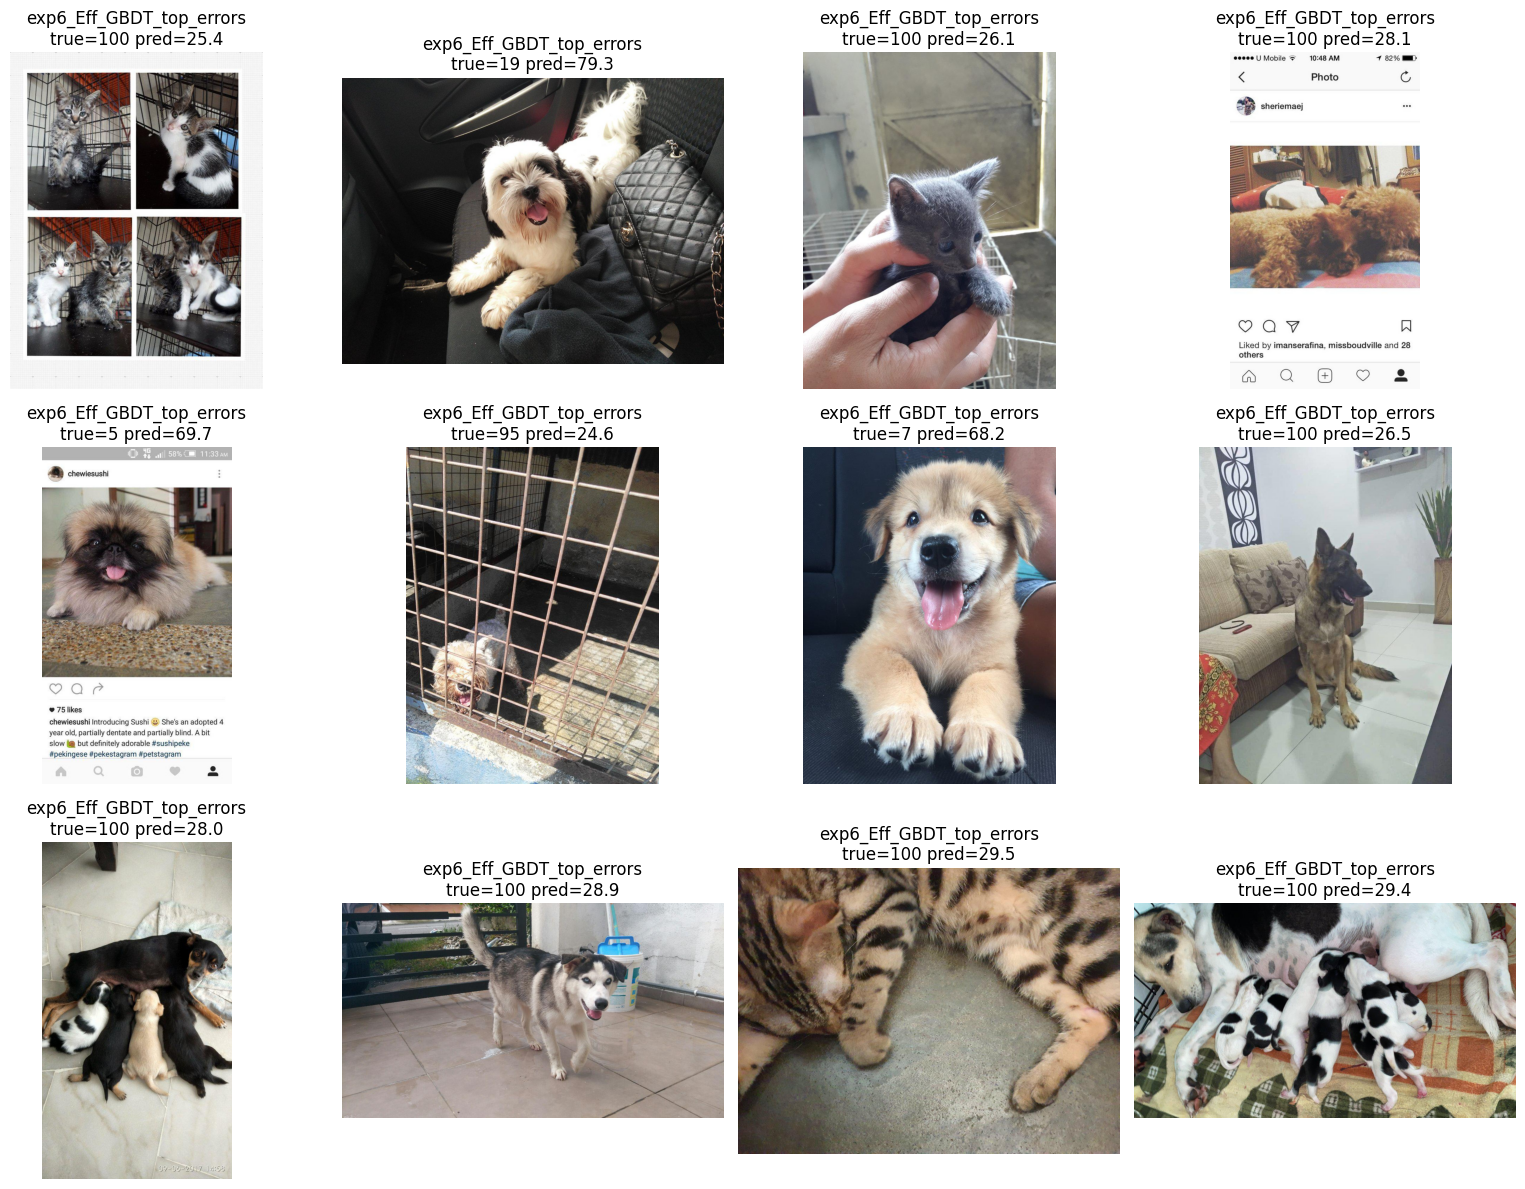

In [80]:
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp6_Eff_GBDT_top_errors")

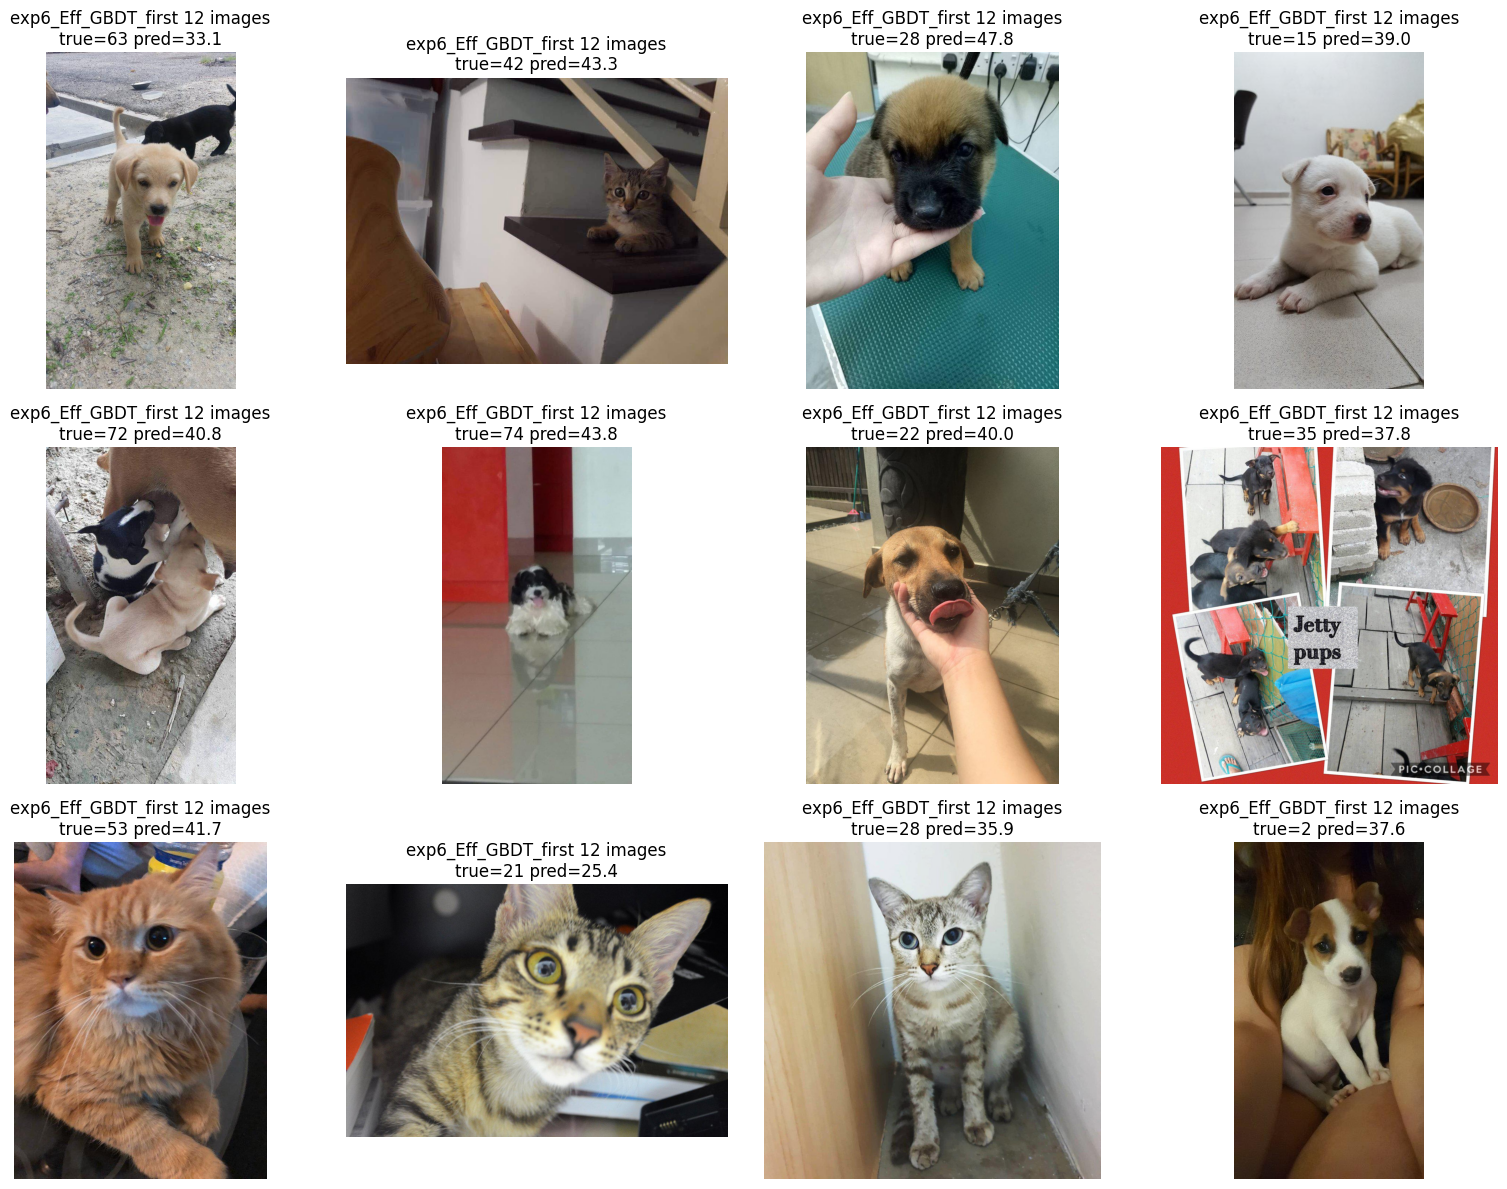

In [81]:
oof_df = oof_df.rename(columns={"final_pred": "oof_pred"})
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp6_Eff_GBDT_first 12 images")